Mục tiêu:

```
Tự xây dựng một CNN hoàn chỉnh bằng các lớp:

Convolution
ReLU
Pooling
Flatten
Dense
Softmax

↓

Prediction
```

In [18]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.simple_cnn import SimpleCNN

from src.utils import (
    load_image,
    show_image,
    image_info
)

from src.utils import plot_feature_maps

In [2]:
print("=" * 60)
print("CNN FROM SCRATCH")
print("10 - SIMPLE CNN")
print("=" * 60)

CNN FROM SCRATCH
10 - SIMPLE CNN


1. CNN Architecture

```
Simple CNN

Input Image
      ↓
Convolution
      ↓
ReLU
      ↓
Pooling
      ↓
Flatten
      ↓
Dense
      ↓
Softmax
      ↓
Prediction
```

2. Load Image

In [3]:
image = load_image(
    "../data/sample.jpg",
    grayscale=True
)

image_info(image)


Image Information
----------------------------------------
Shape : (1, 1080, 1920)
Dtype : uint8
Min   : 0
Max   : 255
----------------------------------------


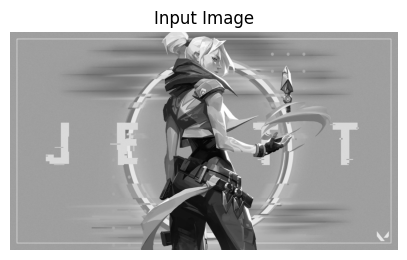

In [4]:
show_image(
    image,
    title="Input Image"
)

In [5]:
print(
    "Input Shape:",
    image.shape
)

Input Shape: (1, 1080, 1920)


3. Create CNN

In [7]:
cnn = SimpleCNN(
    input_shape=image.shape,
    num_classes=10
)

In [8]:
cnn.summary()


SimpleCNN

Convolution2D
----------------------------------------
In Channels : 1
Out Channels: 8
Kernel Size : 3
Stride      : 1
Padding     : 1
Parameters  : 80
----------------------------------------

MaxPooling2D
----------------------------------------
Pool Size : 2
Stride    : 2
----------------------------------------

Dense
----------------------------------------
Input Dim  : 4147200
Output Dim : 10
Parameters : 41472010
----------------------------------------

Total Parameters
--------------------------------------------------
41472090


4. Forward Pass

In [10]:
probabilities = cnn.forward(
    image
)

In [11]:
print(
    probabilities.shape
)

(10,)


In [12]:
print(probabilities)

[7.59026235e-010 2.25846870e-146 9.14328748e-111 2.02609843e-106
 6.83865164e-056 2.65590700e-026 3.83414117e-071 7.08679790e-034
 9.60774223e-007 9.99999038e-001]


In [13]:
print(
    "Sum:",
    probabilities.sum()
)

Sum: 1.0


5. Visualize Prediction

In [14]:
prediction = np.argmax(
    probabilities
)

print(
    "Predicted Class:",
    prediction
)

Predicted Class: 9


6. Inspect Internal Layers

In [15]:
conv_output = cnn.conv.forward(
    image
)

print(
    conv_output.shape
)

(8, 1080, 1920)


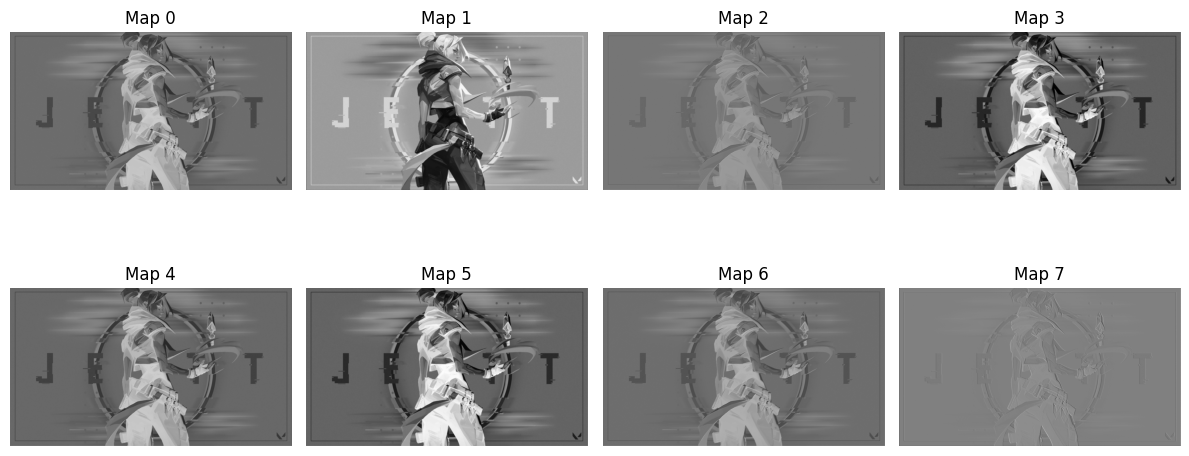

In [19]:
plot_feature_maps(
    conv_output
)

In [20]:
relu_output = cnn.relu.forward(
    conv_output
)

print(
    relu_output.shape
)

(8, 1080, 1920)


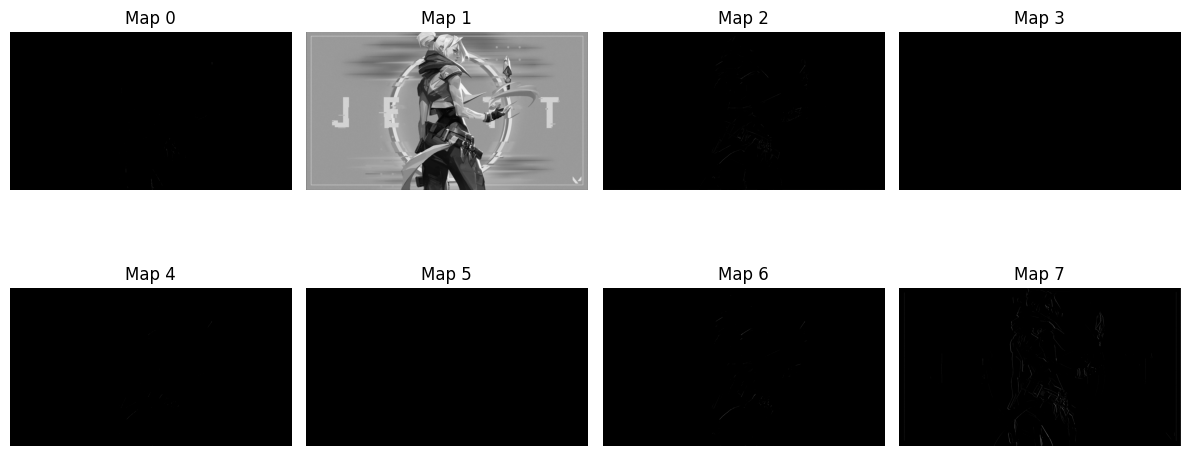

In [21]:
plot_feature_maps(
    relu_output
)

In [22]:
pool_output = cnn.pool.forward(
    relu_output
)

print(
    pool_output.shape
)

(8, 540, 960)


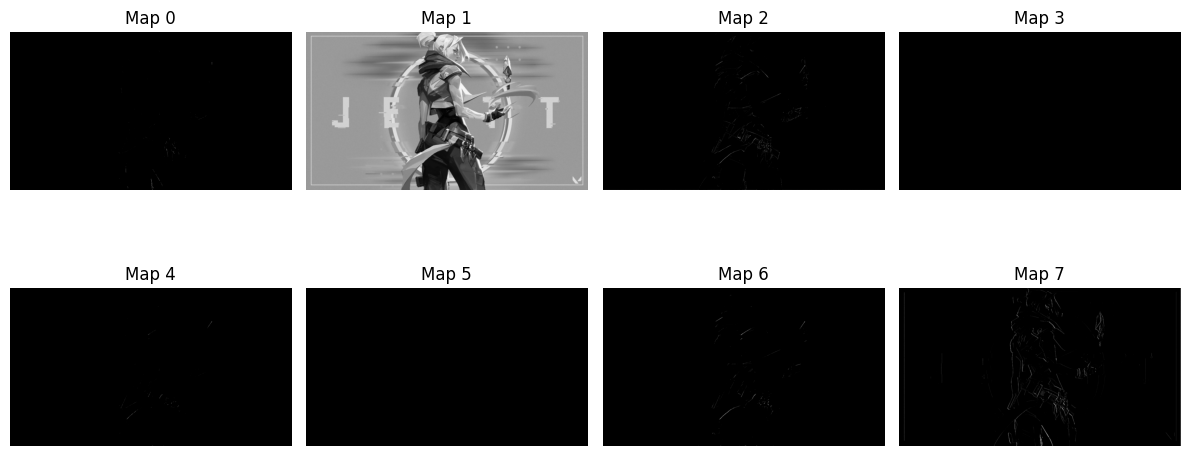

In [23]:
plot_feature_maps(
    pool_output
)

In [24]:
flatten_output = cnn.flatten.forward(
    pool_output
)

In [25]:
print(
    flatten_output.shape
)

(4147200,)


In [26]:
print(
    flatten_output[:20]
)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [27]:
dense_output = cnn.dense.forward(
    flatten_output
)

In [28]:
print(
    dense_output.shape
)

(10,)


In [29]:
print(dense_output)

[ 148.01155907 -166.35219271  -84.36338148  -74.35736403   41.98836922
  110.12011764    6.8709477    92.68088428  155.15501745  169.01054288]


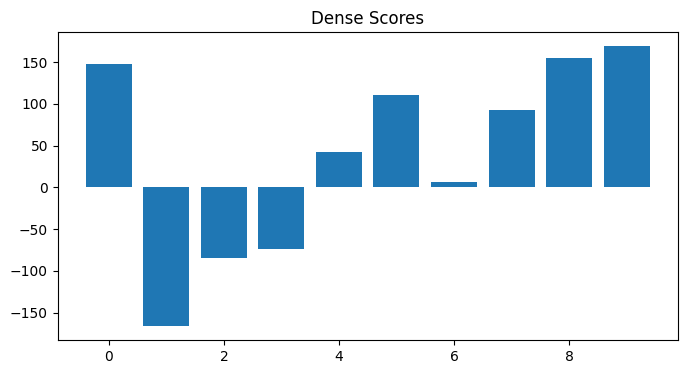

In [30]:
plt.figure(figsize=(8,4))

plt.bar(
    np.arange(10),
    dense_output
)

plt.title(
    "Dense Scores"
)

plt.show()

In [31]:
softmax_output = cnn.softmax.forward(
    dense_output
)

In [32]:
print(
    softmax_output
)

[7.59026235e-010 2.25846870e-146 9.14328748e-111 2.02609843e-106
 6.83865164e-056 2.65590700e-026 3.83414117e-071 7.08679790e-034
 9.60774223e-007 9.99999038e-001]


In [33]:
print(
    softmax_output.sum()
)

1.0


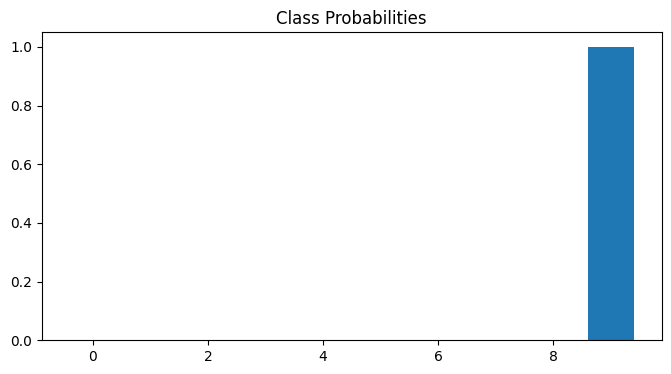

In [34]:
plt.figure(figsize=(8,4))

plt.bar(
    np.arange(10),
    softmax_output
)

plt.title(
    "Class Probabilities"
)

plt.show()

Parameter Count

In [35]:
print(
    "Conv Parameters:",
    cnn.conv.num_parameters
)

Conv Parameters: 80


In [36]:
print(
    "Dense Parameters:",
    cnn.dense.num_parameters
)

Dense Parameters: 41472010


In [37]:
print(
    "Total Parameters:",
    cnn.num_parameters
)

Total Parameters: 41472090
